# Домашняя работа №2: сегментация Oxford-IIIT Pet

**ФИО:** укажите перед сдачей

### Краткий результат

- Лучший вариант grid search: `learning_rate=1e-3`, `batch_size=16`.
- Baseline U-Net: test IoU **0.6650**, Dice/F1 **0.7842**.
- U-Net + GroupNorm: test IoU **0.6989**, Dice/F1 **0.8092**.
- GroupNorm улучшила test IoU на **0.0339** (3.39 процентного пункта).

Цели эксперимента:

1. Реализовать U-Net для бинарной сегментации питомца.
2. Перебрать 3 значения learning rate и 3 значения batch size.
3. Проверить модификацию U-Net: добавить Group Normalization после свёрток.
4. Сравнить варианты по IoU, Dice/F1 и loss на фиксированном разбиении данных.

## 1. Setup

Все параметры эксперимента собраны в конфиге. Seed, разбиение train/validation и preprocessing одинаковы для всех запусков.

In [1]:
from copy import deepcopy
from dataclasses import dataclass, field
from itertools import product
from pathlib import Path
import gc
import os
import random

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode


def get_device():
    if torch.cuda.is_available():
        return 'cuda'
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def clear_device_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, 'mps') and torch.backends.mps.is_available():
        torch.mps.empty_cache()


seed_everything(42)

In [2]:
@dataclass(frozen=True)
class Config:
    image_size: tuple = (128, 128)
    base_channels: int = 16
    train_split: float = 0.8
    seed: int = 42
    num_workers: int = 0
    device: str = field(default_factory=get_device)
    data_root: Path = field(
        default_factory=lambda: Path(os.getenv('OXFORD_PET_ROOT', 'data'))
    )

    search_epochs: int = 3
    final_epochs: int = 10
    learning_rates: tuple = (1e-4, 3e-4, 1e-3)
    batch_sizes: tuple = (16, 32, 64)
    weight_decay: float = 0.0
    threshold: float = 0.5


config = Config()
config

Config(image_size=(128, 128), base_channels=16, train_split=0.8, seed=42, num_workers=0, device='mps', data_root=PosixPath('/Users/kukuff/Documents/SVO/data'), search_epochs=3, final_epochs=10, learning_rates=(0.0001, 0.0003, 0.001), batch_sizes=(16, 32, 64), weight_decay=0.0, threshold=0.5)

## 2. Data

Согласно официальному `annotations/README`, trimap-маска Oxford-IIIT Pet содержит значения: `1` — foreground (питомец), `2` — background, `3` — not classified (граница). Для простой бинарной постановки положительным классом считаем только `mask == 1`, а значения 2 и 3 относим к отрицательному классу.

Изображение масштабируется bilinear-интерполяцией, маска — строго nearest-neighbor, чтобы не создавать промежуточные классы.

In [3]:
class PetSegmentationDataset(Dataset):
    def __init__(self, root, split='trainval', image_size=(128, 128), download=True):
        self.image_size = image_size
        self.dataset = torchvision.datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',
            download=download,
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, trimap = self.dataset[index]

        image = TF.resize(
            image,
            self.image_size,
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.5] * 3, std=[0.5] * 3)

        binary_mask = (np.asarray(trimap) == 1).astype(np.uint8)
        binary_mask = Image.fromarray(binary_mask)
        binary_mask = TF.resize(
            binary_mask,
            self.image_size,
            interpolation=InterpolationMode.NEAREST,
        )
        binary_mask = TF.pil_to_tensor(binary_mask).float()

        return image, binary_mask


full_train_dataset = PetSegmentationDataset(
    config.data_root, split='trainval', image_size=config.image_size
)
test_dataset = PetSegmentationDataset(
    config.data_root, split='test', image_size=config.image_size
)

train_size = int(config.train_split * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
split_generator = torch.Generator().manual_seed(config.seed)
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=split_generator,
)

print(f'train={len(train_dataset)}, validation={len(val_dataset)}, test={len(test_dataset)}')

train=2944, validation=736, test=3669


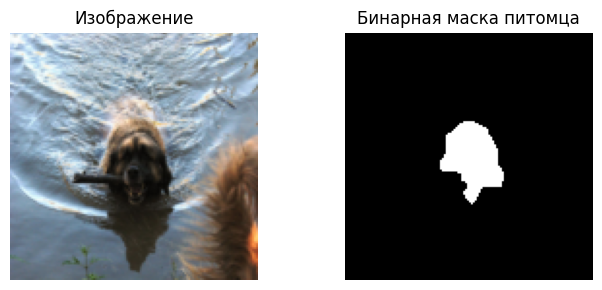

image: (3, 128, 128) mask: (1, 128, 128)
mask values: [0.0, 1.0]


In [4]:
def denormalize_image(image):
    return (image * 0.5 + 0.5).clamp(0, 1)


sample_image, sample_mask = train_dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(denormalize_image(sample_image).permute(1, 2, 0))
axes[0].set_title('Изображение')
axes[1].imshow(sample_mask.squeeze(0), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Бинарная маска питомца')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
display(fig)
plt.close(fig)

print('image:', tuple(sample_image.shape), 'mask:', tuple(sample_mask.shape))
print('mask values:', torch.unique(sample_mask).tolist())

## 3. U-Net

Базовая модель использует три уровня encoder/decoder и skip connections. Модификация управляется параметром `normalization`: при значении `group` после каждой свёртки добавляется GroupNorm. Она не зависит от статистик текущего batch и подходит для сегментации с небольшими batch size.

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, normalization='none'):
        super().__init__()

        def norm_layer():
            if normalization == 'group':
                groups = min(8, out_channels)
                while out_channels % groups != 0:
                    groups -= 1
                return nn.GroupNorm(groups, out_channels)
            return nn.Identity()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            norm_layer(),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            norm_layer(),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=16, normalization='none'):
        super().__init__()
        channels = base_channels

        self.encoder1 = ConvBlock(in_channels, channels, normalization)
        self.encoder2 = ConvBlock(channels, channels * 2, normalization)
        self.encoder3 = ConvBlock(channels * 2, channels * 4, normalization)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = ConvBlock(channels * 4, channels * 8, normalization)

        self.up3 = nn.ConvTranspose2d(channels * 8, channels * 4, kernel_size=2, stride=2)
        self.decoder3 = ConvBlock(channels * 8, channels * 4, normalization)
        self.up2 = nn.ConvTranspose2d(channels * 4, channels * 2, kernel_size=2, stride=2)
        self.decoder2 = ConvBlock(channels * 4, channels * 2, normalization)
        self.up1 = nn.ConvTranspose2d(channels * 2, channels, kernel_size=2, stride=2)
        self.decoder1 = ConvBlock(channels * 2, channels, normalization)

        self.output = nn.Conv2d(channels, out_channels, kernel_size=1)

    def forward(self, x):
        skip1 = self.encoder1(x)
        skip2 = self.encoder2(self.pool(skip1))
        skip3 = self.encoder3(self.pool(skip2))

        x = self.bottleneck(self.pool(skip3))

        x = self.up3(x)
        x = self.decoder3(torch.cat([x, skip3], dim=1))
        x = self.up2(x)
        x = self.decoder2(torch.cat([x, skip2], dim=1))
        x = self.up1(x)
        x = self.decoder1(torch.cat([x, skip1], dim=1))
        return self.output(x)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


with torch.inference_mode():
    check_input = torch.randn(2, 3, *config.image_size)
    baseline_check = UNet(base_channels=config.base_channels, normalization='none')
    modified_check = UNet(base_channels=config.base_channels, normalization='group')
    assert baseline_check(check_input).shape == (2, 1, *config.image_size)
    assert modified_check(check_input).shape == (2, 1, *config.image_size)

print(f'Baseline parameters:  {count_parameters(baseline_check):,}')
print(f'GroupNorm parameters: {count_parameters(modified_check):,}')

Baseline parameters:  481,329
GroupNorm parameters: 482,737


## 4. Training pipeline

Для бинарной сегментации используем сумму BCE и Dice loss. BCE даёт стабильный попиксельный градиент, а Dice-компонента уменьшает влияние дисбаланса между площадью питомца и фона. Качество считаем по IoU и Dice/F1 отдельно для каждого изображения, затем усредняем.

На каждом запуске сохраняются веса с лучшим validation IoU; именно они используются для test-оценки.

In [6]:
def segmentation_metrics(logits, targets, threshold=0.5):
    predictions = torch.sigmoid(logits) >= threshold
    targets = targets >= 0.5
    dimensions = (1, 2, 3)

    intersection = (predictions & targets).sum(dim=dimensions).float()
    union = (predictions | targets).sum(dim=dimensions).float()
    predicted_area = predictions.sum(dim=dimensions).float()
    target_area = targets.sum(dim=dimensions).float()

    eps = 1e-7
    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (predicted_area + target_area + eps)
    return iou, dice


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probabilities = torch.sigmoid(logits)
        dimensions = (1, 2, 3)
        intersection = (probabilities * targets).sum(dim=dimensions)
        denominator = probabilities.sum(dim=dimensions) + targets.sum(dim=dimensions)
        dice_score = (2 * intersection + 1.0) / (denominator + 1.0)
        dice_loss = 1 - dice_score.mean()
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


class SegmentationTrainer:
    def __init__(
        self,
        model,
        train_dataset,
        val_dataset,
        test_dataset,
        *,
        learning_rate,
        batch_size,
        epochs,
        config,
        label,
    ):
        self.config = config
        self.device = torch.device(config.device)
        self.model = model.to(self.device)
        self.label = label
        self.epochs = epochs
        self.criterion = BCEDiceLoss()
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=learning_rate,
            weight_decay=config.weight_decay,
        )

        loader_kwargs = {
            'batch_size': batch_size,
            'num_workers': config.num_workers,
            'pin_memory': self.device.type == 'cuda',
        }
        train_generator = torch.Generator().manual_seed(config.seed)
        self.train_loader = DataLoader(
            train_dataset,
            shuffle=True,
            generator=train_generator,
            **loader_kwargs,
        )
        self.val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
        self.test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_iou': [],
            'val_dice': [],
        }
        self.best_epoch = None
        self.best_val_iou = -np.inf
        self.best_state = None

    def _train_epoch(self):
        self.model.train()
        total_loss = 0.0
        total_samples = 0

        for images, masks in self.train_loader:
            images = images.to(self.device)
            masks = masks.to(self.device)

            self.optimizer.zero_grad(set_to_none=True)
            logits = self.model(images)
            loss = self.criterion(logits, masks)
            loss.backward()
            self.optimizer.step()

            batch_size = masks.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

        return total_loss / total_samples

    @torch.inference_mode()
    def _evaluate(self, loader):
        self.model.eval()
        total_loss = 0.0
        total_iou = 0.0
        total_dice = 0.0
        total_samples = 0

        for images, masks in loader:
            images = images.to(self.device)
            masks = masks.to(self.device)
            logits = self.model(images)
            loss = self.criterion(logits, masks)
            iou, dice = segmentation_metrics(logits, masks, self.config.threshold)

            batch_size = masks.size(0)
            total_loss += loss.item() * batch_size
            total_iou += iou.sum().item()
            total_dice += dice.sum().item()
            total_samples += batch_size

        return {
            'loss': total_loss / total_samples,
            'iou': total_iou / total_samples,
            'dice': total_dice / total_samples,
        }

    def run(self, verbose=True):
        if verbose:
            print(f'{self.label}: device={self.device}, epochs={self.epochs}')

        for epoch in range(self.epochs):
            train_loss = self._train_epoch()
            val_metrics = self._evaluate(self.val_loader)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_metrics['loss'])
            self.history['val_iou'].append(val_metrics['iou'])
            self.history['val_dice'].append(val_metrics['dice'])

            if val_metrics['iou'] > self.best_val_iou:
                self.best_val_iou = val_metrics['iou']
                self.best_epoch = epoch + 1
                self.best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in self.model.state_dict().items()
                }

            if verbose:
                print(
                    f'Epoch {epoch + 1:02d}/{self.epochs}: '
                    f'train loss={train_loss:.4f} | '
                    f'val loss={val_metrics["loss"]:.4f}, '
                    f'IoU={val_metrics["iou"]:.4f}, Dice={val_metrics["dice"]:.4f}'
                )

        self.model.load_state_dict(self.best_state)
        return self.history

    def test(self):
        return self._evaluate(self.test_loader)

## 5. Hyperparameter search: 3 × 3

Перебираем девять комбинаций на базовом U-Net без нормализации. Каждый trial обучается 3 эпохи на полном train split; выбираем комбинацию по лучшему validation IoU. Короткий search нужен, чтобы ограничить вычисления, а выбранные параметры затем проверяются в более длинном финальном запуске.

In [7]:
search_results = []

for learning_rate, batch_size in product(config.learning_rates, config.batch_sizes):
    seed_everything(config.seed)
    trial_label = f'lr={learning_rate:g}, batch={batch_size}'
    trial_model = UNet(
        base_channels=config.base_channels,
        normalization='none',
    )
    trial_trainer = SegmentationTrainer(
        trial_model,
        train_dataset,
        val_dataset,
        test_dataset,
        learning_rate=learning_rate,
        batch_size=batch_size,
        epochs=config.search_epochs,
        config=config,
        label=trial_label,
    )
    trial_history = trial_trainer.run(verbose=False)

    best_epoch_index = int(np.argmax(trial_history['val_iou']))
    result = {
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'best_epoch': best_epoch_index + 1,
        'val_loss': trial_history['val_loss'][best_epoch_index],
        'val_iou': trial_history['val_iou'][best_epoch_index],
        'val_dice': trial_history['val_dice'][best_epoch_index],
    }
    search_results.append(result)
    print(
        f'{trial_label:24s} | best epoch={result["best_epoch"]} | '
        f'val IoU={result["val_iou"]:.4f} | Dice={result["val_dice"]:.4f}'
    )

    trial_trainer.model.to('cpu')
    del trial_trainer, trial_model
    clear_device_cache()

search_df = pd.DataFrame(search_results).sort_values(
    ['val_iou', 'val_dice'], ascending=False
).reset_index(drop=True)
search_df.style.format({
    'learning_rate': '{:.0e}',
    'val_loss': '{:.4f}',
    'val_iou': '{:.4f}',
    'val_dice': '{:.4f}',
})

lr=0.0001, batch=16      | best epoch=3 | val IoU=0.4657 | Dice=0.6204


lr=0.0001, batch=32      | best epoch=3 | val IoU=0.4501 | Dice=0.6061


lr=0.0001, batch=64      | best epoch=3 | val IoU=0.4411 | Dice=0.5970


lr=0.0003, batch=16      | best epoch=3 | val IoU=0.4870 | Dice=0.6394


lr=0.0003, batch=32      | best epoch=3 | val IoU=0.4938 | Dice=0.6476


lr=0.0003, batch=64      | best epoch=3 | val IoU=0.4512 | Dice=0.6067


lr=0.001, batch=16       | best epoch=2 | val IoU=0.5479 | Dice=0.6945


lr=0.001, batch=32       | best epoch=3 | val IoU=0.5225 | Dice=0.6693


lr=0.001, batch=64       | best epoch=3 | val IoU=0.5112 | Dice=0.6636


,learning_rate,batch_size,best_epoch,val_loss,val_iou,val_dice
0,1e-03,16,2,0.3912,0.5479,0.6945
1,1e-03,32,3,0.4350,0.5225,0.6693
2,1e-03,64,3,0.4312,0.5112,0.6636
3,3e-04,32,3,0.4560,0.4938,0.6476
4,3e-04,16,3,0.4370,0.4870,0.6394
5,1e-04,16,3,0.4658,0.4657,0.6204
6,3e-04,64,3,0.5266,0.4512,0.6067
7,1e-04,32,3,0.5170,0.4501,0.6061
8,1e-04,64,3,0.5503,0.4411,0.5970


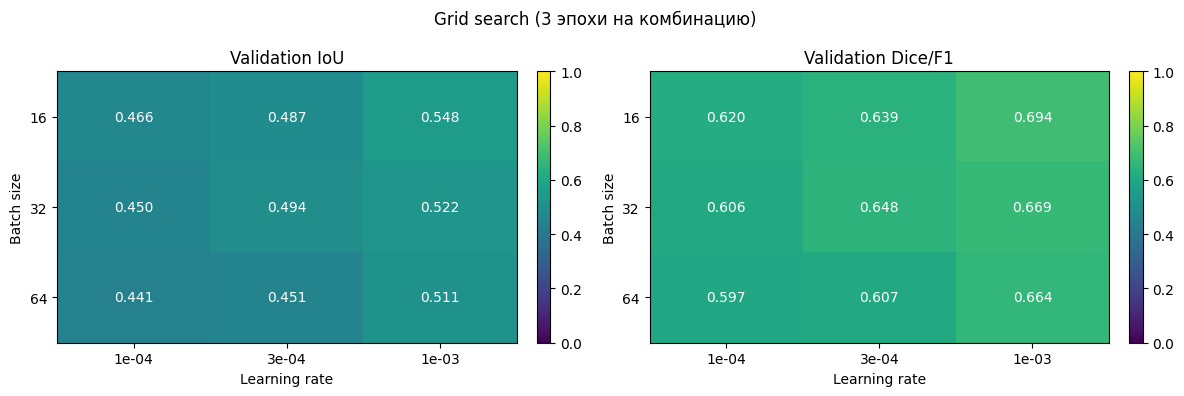

Лучшие параметры: learning_rate=0.001, batch_size=16


In [8]:
metric_names = [('val_iou', 'Validation IoU'), ('val_dice', 'Validation Dice/F1')]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for axis, (metric, title) in zip(axes, metric_names):
    pivot = search_df.pivot(
        index='batch_size', columns='learning_rate', values=metric
    ).sort_index().sort_index(axis=1)
    image = axis.imshow(pivot.values, cmap='viridis', vmin=0, vmax=1, aspect='auto')
    axis.set_xticks(range(len(pivot.columns)), [f'{value:.0e}' for value in pivot.columns])
    axis.set_yticks(range(len(pivot.index)), [str(value) for value in pivot.index])
    axis.set_xlabel('Learning rate')
    axis.set_ylabel('Batch size')
    axis.set_title(title)
    for row in range(pivot.shape[0]):
        for column in range(pivot.shape[1]):
            value = pivot.iloc[row, column]
            axis.text(column, row, f'{value:.3f}', ha='center', va='center', color='white')
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

plt.suptitle(f'Grid search ({config.search_epochs} эпохи на комбинацию)')
plt.tight_layout()
display(fig)
plt.close(fig)

best_search = search_df.iloc[0]
best_learning_rate = float(best_search['learning_rate'])
best_batch_size = int(best_search['batch_size'])
print(f'Лучшие параметры: learning_rate={best_learning_rate:g}, batch_size={best_batch_size}')

## 6. Финальный эксперимент: базовый U-Net vs GroupNorm

Обе модели обучаются с нуля 10 эпох на лучшей комбинации из grid search. Единственное различие — наличие GroupNorm, поэтому изменение метрик можно связывать с проверяемой модификацией.

In [9]:
final_trainers = {}

for label, normalization in [('Baseline U-Net', 'none'), ('U-Net + GroupNorm', 'group')]:
    seed_everything(config.seed)
    model = UNet(
        base_channels=config.base_channels,
        normalization=normalization,
    )
    trainer = SegmentationTrainer(
        model,
        train_dataset,
        val_dataset,
        test_dataset,
        learning_rate=best_learning_rate,
        batch_size=best_batch_size,
        epochs=config.final_epochs,
        config=config,
        label=label,
    )
    trainer.run(verbose=True)
    trainer.test_metrics = trainer.test()
    final_trainers[label] = trainer
    print(
        f'Best epoch={trainer.best_epoch}; '
        f'test loss={trainer.test_metrics["loss"]:.4f}, '
        f'IoU={trainer.test_metrics["iou"]:.4f}, '
        f'Dice={trainer.test_metrics["dice"]:.4f}\n'
    )

Baseline U-Net: device=mps, epochs=10


Epoch 01/10: train loss=0.5395 | val loss=0.4635, IoU=0.5158, Dice=0.6648


Epoch 02/10: train loss=0.4213 | val loss=0.3912, IoU=0.5479, Dice=0.6945


Epoch 03/10: train loss=0.3942 | val loss=0.3950, IoU=0.5271, Dice=0.6740


Epoch 04/10: train loss=0.3739 | val loss=0.3595, IoU=0.5773, Dice=0.7175


...

Epoch 07/10: train loss=0.2738 | val loss=0.2898, IoU=0.6551, Dice=0.7790


Epoch 08/10: train loss=0.2540 | val loss=0.2473, IoU=0.7029, Dice=0.8151


Epoch 09/10: train loss=0.2449 | val loss=0.2397, IoU=0.7083, Dice=0.8188


Epoch 10/10: train loss=0.2397 | val loss=0.2470, IoU=0.7000, Dice=0.8128


Best epoch=9; test loss=0.2502, IoU=0.6989, Dice=0.8092



## 7. Результаты

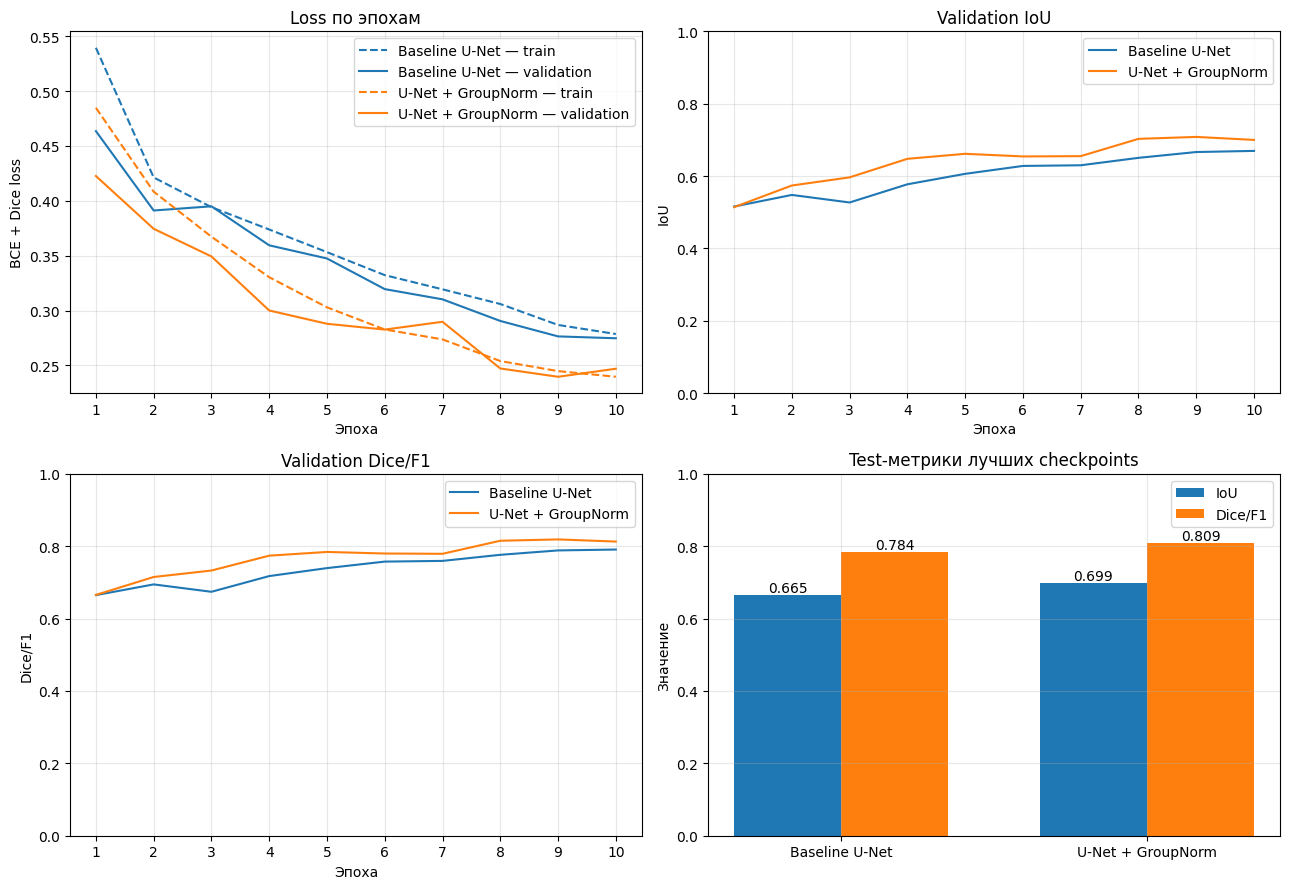

In [10]:
colors = {'Baseline U-Net': 'tab:blue', 'U-Net + GroupNorm': 'tab:orange'}
epochs = np.arange(1, config.final_epochs + 1)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for label, trainer in final_trainers.items():
    color = colors[label]
    axes[0, 0].plot(epochs, trainer.history['train_loss'], '--', color=color, label=f'{label} — train')
    axes[0, 0].plot(epochs, trainer.history['val_loss'], '-', color=color, label=f'{label} — validation')
    axes[0, 1].plot(epochs, trainer.history['val_iou'], color=color, label=label)
    axes[1, 0].plot(epochs, trainer.history['val_dice'], color=color, label=label)

axes[0, 0].set(title='Loss по эпохам', xlabel='Эпоха', ylabel='BCE + Dice loss')
axes[0, 1].set(title='Validation IoU', xlabel='Эпоха', ylabel='IoU', ylim=(0, 1))
axes[1, 0].set(title='Validation Dice/F1', xlabel='Эпоха', ylabel='Dice/F1', ylim=(0, 1))

labels = list(final_trainers)
positions = np.arange(len(labels))
bar_width = 0.35
test_ious = [final_trainers[label].test_metrics['iou'] for label in labels]
test_dices = [final_trainers[label].test_metrics['dice'] for label in labels]
iou_bars = axes[1, 1].bar(positions - bar_width / 2, test_ious, bar_width, label='IoU')
dice_bars = axes[1, 1].bar(positions + bar_width / 2, test_dices, bar_width, label='Dice/F1')
axes[1, 1].set(title='Test-метрики лучших checkpoints', ylabel='Значение', ylim=(0, 1))
axes[1, 1].set_xticks(positions, labels)
axes[1, 1].bar_label(iou_bars, fmt='%.3f')
axes[1, 1].bar_label(dice_bars, fmt='%.3f')

for axis in axes.flat:
    axis.grid(alpha=0.3)
    axis.legend()
axes[0, 0].set_xticks(epochs)
axes[0, 1].set_xticks(epochs)
axes[1, 0].set_xticks(epochs)
plt.tight_layout()
display(fig)
plt.close(fig)

In [11]:
summary_rows = []
for label, trainer in final_trainers.items():
    summary_rows.append({
        'model': label,
        'best_epoch': trainer.best_epoch,
        'best_val_iou': trainer.best_val_iou,
        'test_loss': trainer.test_metrics['loss'],
        'test_iou': trainer.test_metrics['iou'],
        'test_dice': trainer.test_metrics['dice'],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.style.format({
    'best_val_iou': '{:.4f}',
    'test_loss': '{:.4f}',
    'test_iou': '{:.4f}',
    'test_dice': '{:.4f}',
})

,model,best_epoch,best_val_iou,test_loss,test_iou,test_dice
0,Baseline U-Net,10,0.6696,0.2798,0.6650,0.7842
1,U-Net + GroupNorm,9,0.7083,0.2502,0.6989,0.8092


## 8. Качественная проверка на test-изображениях

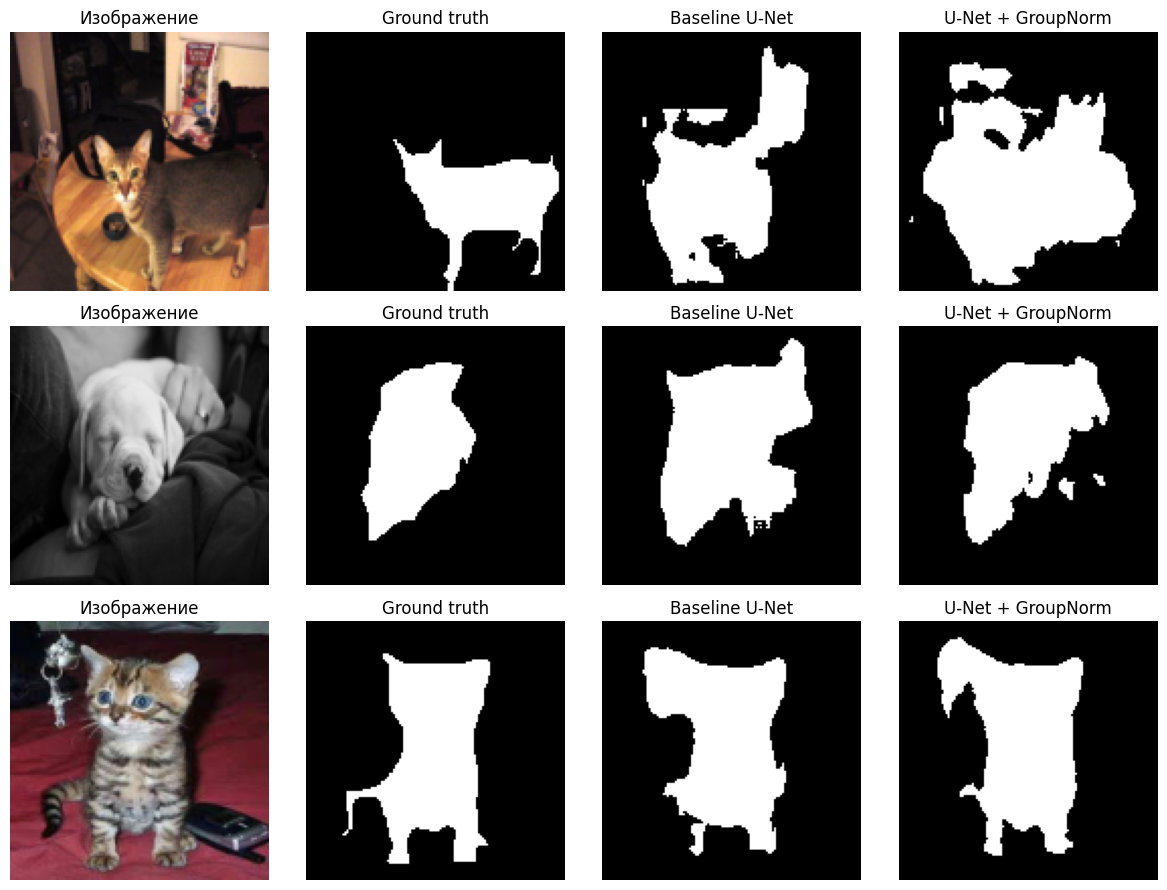

In [12]:
sample_indices = [0, 100, 500]
fig, axes = plt.subplots(len(sample_indices), 4, figsize=(12, 9))

for row, sample_index in enumerate(sample_indices):
    image, target_mask = test_dataset[sample_index]
    axes[row, 0].imshow(denormalize_image(image).permute(1, 2, 0))
    axes[row, 0].set_title('Изображение')
    axes[row, 1].imshow(target_mask.squeeze(0), cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title('Ground truth')

    for column, label in enumerate(final_trainers, start=2):
        trainer = final_trainers[label]
        trainer.model.eval()
        with torch.inference_mode():
            logits = trainer.model(image.unsqueeze(0).to(trainer.device))
            prediction = (torch.sigmoid(logits) >= config.threshold).float()
        axes[row, column].imshow(prediction[0, 0].cpu(), cmap='gray', vmin=0, vmax=1)
        axes[row, column].set_title(label)

    for axis in axes[row]:
        axis.axis('off')

plt.tight_layout()
display(fig)
plt.close(fig)

## 9. Выводы

1. **Grid search.** Лучшей стала комбинация `learning_rate=1e-3`, `batch_size=16`: validation IoU = **0.5479**, Dice/F1 = **0.6945** за три search-эпохи. На каждом batch size увеличение learning rate до `1e-3` улучшало результат. При коротком обучении больший шаг позволил модели быстрее выйти из начальной области параметров.

2. **Влияние batch size.** При `lr=1e-3` уменьшение batch size с 64 до 16 повысило validation IoU с **0.5112** до **0.5479**. При фиксированном числе эпох batch size 16 даёт больше обновлений весов, а более шумный градиент может помогать обобщению. Поэтому результат нельзя интерпретировать только как эффект размера batch: одновременно меняется число optimizer steps.

3. **Проверка модификации.** Baseline U-Net получил test IoU **0.6650**, Dice/F1 **0.7842** и loss **0.2798**. Добавление GroupNorm улучшило test IoU до **0.6989**, Dice/F1 до **0.8092**, а loss снизило до **0.2502**. Улучшение IoU составило **3.39 процентного пункта**. Вероятное объяснение — нормализация стабилизирует масштабы признаков внутри encoder/decoder и не зависит от статистик batch, что особенно полезно при batch size 16.

4. **Выбор checkpoint.** У GroupNorm лучший validation IoU (**0.7083**) получен на 9-й эпохе, а на 10-й снизился до 0.7000. В test использованы веса 9-й эпохи, поэтому сохранение лучшего checkpoint предотвращает ухудшение от последней эпохи.

5. **Ограничения.** Grid search сравнивает раннюю скорость сходимости, поскольку каждая комбинация обучалась только три эпохи. Эксперимент выполнен с одним seed и без аугментаций, поэтому для более строгого вывода нужны повторные запуски с несколькими seed и более длинный search.